In [ ]:
# Name: DVN Surya Kiran
# Roll No: CH.SC.U4CSE24116
# Lab 9 Exercise 2 - KNN Color Classification (Euclidean Distance)

In [ ]:
import pandas as pd
import numpy as np
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn import metrics
import matplotlib.pyplot as plt
import seaborn as sn

In [ ]:
data = {
    'Brightness': [40, 50, 60, 10, 70, 60, 25],
    'Saturation': [20, 50, 90, 25, 70, 10, 80],
    'Class':      ['Red', 'Blue', 'Blue', 'Red', 'Blue', 'Red', 'Blue']
}
df = pd.DataFrame(data)
print(df)

   Brightness  Saturation Class
0          40          20   Red
1          50          50  Blue
2          60          90  Blue
3          10          25   Red
4          70          70  Blue
5          60          10   Red
6          25          80  Blue


In [ ]:
print(df.isnull().sum())
print(df.shape)

Brightness    0
Saturation    0
Class         0
dtype: int64
(7, 3)


In [ ]:
new_point = np.array([45, 55])
print("Euclidean distances from new point (45, 55):\n")
for i, row in df.iterrows():
    dist = np.sqrt((row['Brightness'] - new_point[0])**2 +
                   (row['Saturation'] - new_point[1])**2)
    print(f"Point {i+1} | Brightness:{row['Brightness']} Saturation:{row['Saturation']} | Class:{row['Class']} | Distance:{dist:.2f}")

Euclidean distances from new point (45, 55):

Point 1 | Brightness:40 Saturation:20 | Class:Red | Distance:35.36
Point 2 | Brightness:50 Saturation:50 | Class:Blue | Distance:7.07
Point 3 | Brightness:60 Saturation:90 | Class:Blue | Distance:38.08
Point 4 | Brightness:10 Saturation:25 | Class:Red | Distance:46.10
Point 5 | Brightness:70 Saturation:70 | Class:Blue | Distance:29.15
Point 6 | Brightness:60 Saturation:10 | Class:Red | Distance:47.43
Point 7 | Brightness:25 Saturation:80 | Class:Blue | Distance:32.02


In [ ]:
df['Class_Encoded'] = df['Class'].map({'Red': 0, 'Blue': 1})
x = df[['Brightness', 'Saturation']]
y = df['Class_Encoded']
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=42)
print(x_train.shape, x_test.shape)

(4, 2) (3, 2)


In [ ]:
sc = StandardScaler()
x_train_sc = sc.fit_transform(x_train)
x_test_sc = sc.transform(x_test)

In [ ]:
results = []
for k in [1, 2, 3]:
    model = KNeighborsClassifier(n_neighbors=k, metric='minkowski', p=2)
    model.fit(x_train_sc, y_train)
    y_pred = model.predict(x_test_sc)
    acc = metrics.accuracy_score(y_test, y_pred)
    results.append(acc)
    print(f"K={k} Accuracy: {int(acc*100)}%")

K=1 Accuracy: 100%
K=2 Accuracy: 100%
K=3 Accuracy: 33%


In [ ]:
model = KNeighborsClassifier(n_neighbors=1, metric='minkowski', p=2)
model.fit(x_train_sc, y_train)
y_pred = model.predict(x_test_sc)
print("Predicted:", ['Red' if p==0 else 'Blue' for p in y_pred])
print("Actual:   ", ['Red' if p==0 else 'Blue' for p in y_test.values])

Predicted: ['Red', 'Blue', 'Red']
Actual:    ['Red', 'Blue', 'Red']


In [ ]:
conf_mat = metrics.confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", conf_mat)
print("Accuracy:", metrics.accuracy_score(y_test, y_pred))
print("Accuracy %:", int(metrics.accuracy_score(y_test, y_pred)*100), '%')

Confusion Matrix:
 [[2 0]
 [0 1]]
Accuracy: 1.0
Accuracy %: 100 %


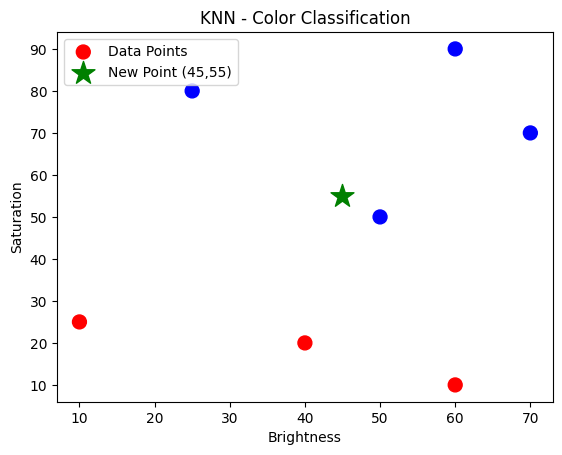

In [ ]:
colors = ['red' if c == 'Red' else 'blue' for c in df['Class']]
plt.scatter(df['Brightness'], df['Saturation'], c=colors, s=100, label='Data Points')
plt.scatter(45, 55, c='green', marker='*', s=300, label='New Point (45,55)')
plt.xlabel('Brightness')
plt.ylabel('Saturation')
plt.title('KNN - Color Classification')
plt.legend()
plt.show()

In [ ]:
print("Observation: Euclidean distance used to find nearest neighbors.")
print("New point (45,55) is classified based on majority class of K nearest neighbors.")
print("Higher saturation + brightness → Blue | Lower values → Red")

Observation: Euclidean distance used to find nearest neighbors.
New point (45,55) is classified based on majority class of K nearest neighbors.
Higher saturation + brightness → Blue | Lower values → Red
